# 📊 Análise Exploratória de Dados (EDA) — Inadimplência em Crédito

## 📌 Objetivo
Este projeto tem como objetivo realizar uma Análise Exploratória de Dados (EDA) para identificar padrões e fatores associados à inadimplência de clientes em operações de crédito.

A partir dessa análise, buscamos gerar insights que auxiliem na construção de modelos preditivos de risco, contribuindo para decisões mais assertivas na concessão de crédito.

---

## 💼 Contexto de Negócio
Instituições financeiras enfrentam desafios constantes na gestão de risco de crédito. A inadimplência impacta diretamente a rentabilidade, tornando essencial a identificação antecipada de clientes com maior probabilidade de default.

Neste contexto, variáveis como histórico financeiro, comportamento de pagamento e perfil do cliente são fundamentais para avaliar o risco.


# Importação de Bibliotecas e Configurações Iniciais

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set(style="whitegrid")

# 1. Tratamento e Verificação dos Dados

In [2]:
# Importando a Base de Dados e lenda as 5 primeiras linhas
dados = pd.read_csv('/content/payflow_credit_risk.csv')
dados.head()

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,...,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,canal_aquisicao,regiao,tipo_produto,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,status_apos_90d,default_90d
0,1,22,2639.75,2.718888,0,617.0,2619.14,12,3.96,3,...,0,0,0,site,Sul,emprestimo_pessoal,0,29,default,1
1,2,59,2482.34,10.785992,0,619.0,9101.21,36,3.37,2,...,0,0,0,app,Sudeste,cartao,2,10,em_dia,0
2,3,52,6230.69,9.547608,0,665.0,13258.67,48,3.12,0,...,0,0,0,loja,Sudeste,cartao,2,0,em_dia,0
3,4,41,6469.45,4.287084,0,676.0,1407.28,12,1.52,2,...,90,1,0,parceiro,Sudeste,emprestimo_pessoal,3,0,em_dia,0
4,5,40,2343.04,0.000000,0,671.0,2647.92,48,3.07,1,...,15,0,0,app,Nordeste,bnpl,2,10,em_atraso_leve,0


## 🔍 Visão Inicial dos Dados

- Dataset com **5.000 registros** e **23 variáveis**
- Tipos de dados:
  - Numéricas: maioria (int64 e float64)
  - Categóricas: `canal_aquisicao`, `regiao`, `tipo_produto`, `status_apos_90d`


In [3]:
# Verificando as informações do Dataset - tipo de colunas e valores nulos
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_cliente                    5000 non-null   int64  
 1   idade                         5000 non-null   int64  
 2   renda_mensal                  4808 non-null   float64
 3   tempo_emprego_anos            4474 non-null   float64
 4   autonomo                      5000 non-null   int64  
 5   score_credito                 5000 non-null   float64
 6   valor_solicitado              5000 non-null   float64
 7   prazo_meses                   5000 non-null   int64  
 8   juros_mensal_pct              5000 non-null   float64
 9   qtde_cartoes                  5000 non-null   int64  
 10  qtde_contratos_abertos        5000 non-null   int64  
 11  utilizacao_credito            5000 non-null   float64
 12  inadimplencias_anteriores     5000 non-null   int64  
 13  dia

In [4]:
print(f'Tamanho do Dataset (linhas, colunas): {dados.shape}')

Tamanho do Dataset (linhas, colunas): (5000, 23)



## 📊 Qualidade dos Dados

### Valores Nulos
- `renda_mensal`: 192 valores nulos
- `tempo_emprego_anos`: 526 valores nulos
- Demais variáveis: completas

In [5]:
# Verificando a somatória dos valores nulos de cada coluna
print(dados.isnull().sum())

id_cliente                        0
idade                             0
renda_mensal                    192
tempo_emprego_anos              526
autonomo                          0
score_credito                     0
valor_solicitado                  0
prazo_meses                       0
juros_mensal_pct                  0
qtde_cartoes                      0
qtde_contratos_abertos            0
utilizacao_credito                0
inadimplencias_anteriores         0
dias_atraso_max_12m               0
reclamacoes_6m                    0
possui_avalista                   0
canal_aquisicao                   0
regiao                            0
tipo_produto                      0
parcelas_pagas_ate_3m             0
atraso_primeira_parcela_dias      0
status_apos_90d                   0
default_90d                       0
dtype: int64


### Tratamento Realizado
- `renda_mensal`: imputação pela **mediana**
- `tempo_emprego_anos`: preenchido com **0** (interpretação: sem vínculo empregatício)

✔ Após tratamento: **nenhum valor nulo restante**


In [6]:
# Renda mensal - iremos calcular a mediana da renda mensal e substituir os valores nulos
mediana = dados['renda_mensal'].median()
dados['renda_mensal'] = dados['renda_mensal'].fillna(mediana)

In [7]:
# Tempo_emprego_anos - iremos zerar, pois entende que a pessoa está desempregada
dados['tempo_emprego_anos'] = dados['tempo_emprego_anos'].fillna(0)

In [8]:
print(dados.isnull().sum())

id_cliente                      0
idade                           0
renda_mensal                    0
tempo_emprego_anos              0
autonomo                        0
score_credito                   0
valor_solicitado                0
prazo_meses                     0
juros_mensal_pct                0
qtde_cartoes                    0
qtde_contratos_abertos          0
utilizacao_credito              0
inadimplencias_anteriores       0
dias_atraso_max_12m             0
reclamacoes_6m                  0
possui_avalista                 0
canal_aquisicao                 0
regiao                          0
tipo_produto                    0
parcelas_pagas_ate_3m           0
atraso_primeira_parcela_dias    0
status_apos_90d                 0
default_90d                     0
dtype: int64



## 🧹 Dados Duplicados

- Nenhum registro duplicado encontrado


In [9]:
# Verificando se existem dados duplicados
print(f'Total de dados duplicados : {dados.duplicated().sum()}')

Total de dados duplicados : 0


## 📊 Estatísticas Descritivas

A análise estatística inicial das variáveis numéricas permite compreender a distribuição dos dados e identificar possíveis padrões relevantes relacionados ao risco de inadimplência.

### 🔎 Observações importantes:

- A idade média dos clientes é de aproximadamente **44 anos**, com variação entre **18 e 70 anos**, indicando uma base composta majoritariamente por adultos economicamente ativos  

- A renda mensal média é de cerca de **4.647**, com valores que chegam até **35.000**, evidenciando alta variabilidade e possível presença de outliers  

- O score de crédito médio é de aproximadamente **653 pontos**, variando entre **350 e 900**, o que sugere uma base com perfis de risco bastante distintos  

- O valor médio solicitado é de aproximadamente **11.277**, podendo atingir até **60.000**, indicando diferentes níveis de exposição ao risco  

- O prazo médio dos empréstimos é de **25 meses**, com contratos que chegam até **60 meses**, refletindo diferentes horizontes de crédito  

- A taxa média de juros mensal é de cerca de **2,82%**, com variações relevantes entre os clientes  

- A utilização média de crédito é de **33%**, sugerindo um nível moderado de comprometimento da capacidade de crédito  


In [10]:
# Pegando a análise estatística descritiva
dados.describe().round(2)

,id_cliente,idade,renda_mensal,tempo_emprego_anos,autonomo,score_credito,valor_solicitado,prazo_meses,juros_mensal_pct,qtde_cartoes,qtde_contratos_abertos,utilizacao_credito,inadimplencias_anteriores,dias_atraso_max_12m,reclamacoes_6m,possui_avalista,parcelas_pagas_ate_3m,atraso_primeira_parcela_dias,default_90d
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,2500.50,43.93,4647.02,4.27,0.16,653.59,11277.88,25.44,2.82,1.18,1.01,0.33,0.29,12.08,0.42,0.19,2.26,12.72,0.12
std,1443.52,15.34,3934.41,3.64,0.37,85.27,10542.62,15.37,0.93,1.10,1.01,0.18,0.60,24.01,0.66,0.39,0.82,23.67,0.33
min,1.00,18.00,800.00,0.00,0.00,350.00,500.00,6.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1250.75,31.00,2186.32,0.60,0.00,596.00,4466.43,12.00,2.20,0.00,0.00,0.19,0.00,0.00,0.00,0.00,2.00,0.00,0.00
50%,2500.50,44.00,3496.40,4.03,0.00,655.00,7981.62,24.00,2.83,1.00,1.00,0.31,0.00,0.00,0.00,0.00,2.00,5.00,0.00
75%,3750.25,57.00,5675.98,6.79,0.00,711.00,14095.93,36.00,3.45,2.00,2.00,0.45,0.00,15.00,1.00,0.00,3.00,15.00,0.00
max,5000.00,70.00,35000.00,18.79,1.00,900.00,60000.00,60.00,6.30,6.00,7.00,1.00,3.00,120.00,4.00,1.00,3.00,119.00,1.00


## 🚫 Tratamento de Leakage

Algumas variáveis foram removidas por representarem **data leakage**, ou seja, informações que não estariam disponíveis no momento da concessão de crédito.

### 🔎 Variáveis removidas:
- `id_cliente` → identificador irrelevante para modelagem  
- `parcelas_pagas_ate_3m` → comportamento pós-concessão  
- `atraso_primeira_parcela_dias` → informação futura  
- `status_apos_90d` → diretamente relacionada ao target  

### ⚠️ Observação
A remoção dessas variáveis evita que o modelo aprenda padrões irreais, garantindo maior capacidade de generalização.


In [11]:
dados = dados.drop(['id_cliente', 'parcelas_pagas_ate_3m', 'atraso_primeira_parcela_dias', 'status_apos_90d'], axis=1)

## 🎯 Distribuição da Variável Alvo

A variável alvo `default_90d` indica se o cliente entrou em inadimplência em até 90 dias.

### 📊 Proporção das classes:
- **Não inadimplentes (0): 87,82%**  
- **Inadimplentes (1): 12,18%**


In [12]:
dados['default_90d'].value_counts(normalize=True)*100

,proportion
default_90d,
0,87.82
1,12.18


## 🔎 Análise

Observa-se que a inadimplência ocorre em uma parcela menor da base, indicando que a maioria dos clientes mantém seus compromissos financeiros no período analisado.

Essa distribuição é esperada em contextos de crédito, onde eventos de default tendem a ser menos frequentes.


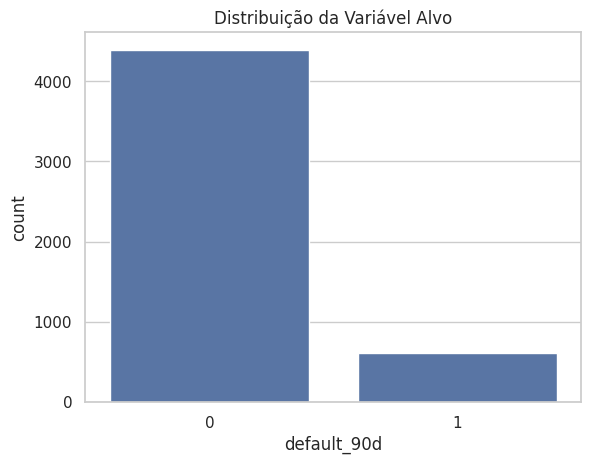

In [13]:
sns.countplot(data=dados, x='default_90d')
plt.title('Distribuição da Variável Alvo')
plt.show()

# 2. 🔍 Fatores Críticos Relacionados à Inadimplência

Nesta etapa, analisamos a relação entre variáveis comportamentais e financeiras com a variável alvo `default_90d`, buscando identificar padrões que diferenciam clientes inadimplentes dos adimplentes.


In [14]:
def plot_triplo(dados, x, y, titulo_y=None):
    fig, ax = plt.subplots(1, 3, figsize=(16,4))

    palette = {
        1: '#2ecc71',
        0: '#b0b0b0'
    }

    # Boxplot
    sns.boxplot(data=dados, x=x, y=y, ax=ax[0], palette=palette, hue=x, legend=False)
    ax[0].set_title(f'Boxplot de {y}')
    ax[0].set_xlabel(x)
    ax[0].set_ylabel(y)

    # Violinplot
    sns.violinplot(data=dados, x=x, y=y, ax=ax[1], palette=palette, hue=x, legend=False)
    ax[1].set_title(f'ViolinPlot de {y}')
    ax[1].set_xlabel(x)
    ax[1].set_ylabel(y)

    # KDE plot
    sns.kdeplot(data=dados, x=y, hue=x, ax=ax[2], fill=True, common_norm=False)
    ax[2].set_title(f'Densidade de {y}')
    ax[2].set_xlabel(y)

    plt.tight_layout()
    plt.show()


## ⏱️ Dias de Atraso (últimos 12 meses)

### 🔎 Análise

- Clientes **inadimplentes (1)** apresentam distribuição significativamente mais dispersa  
- A mediana de atraso é maior para inadimplentes  
- Há maior concentração de valores elevados (cauda longa)

### 💡 Insight

O histórico recente de atraso é um dos sinais mais fortes de risco.  
Clientes com maior número de dias em atraso tendem a apresentar maior probabilidade de inadimplência futura.


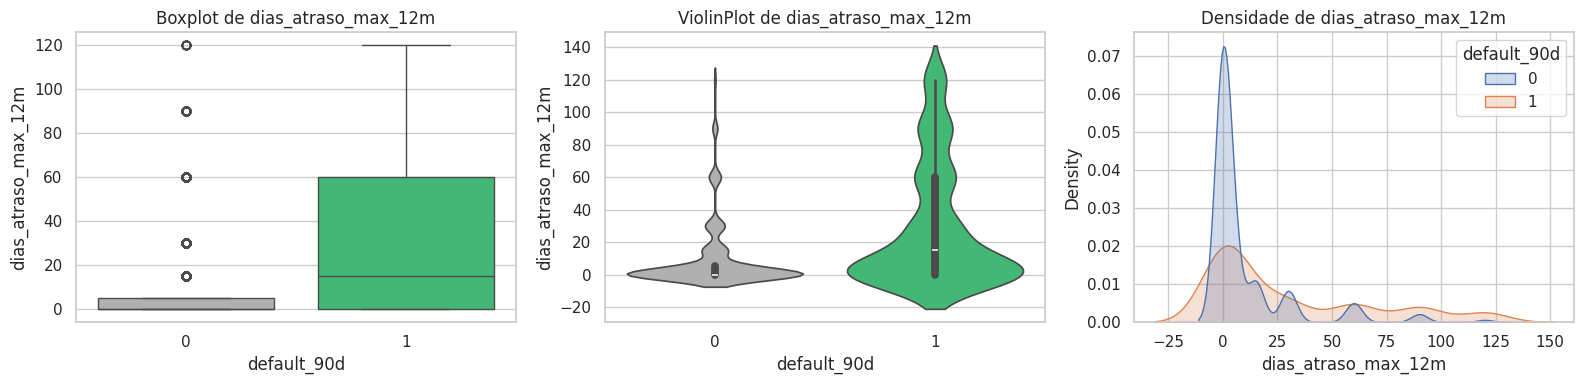

In [15]:
plot_triplo(dados, 'default_90d', 'dias_atraso_max_12m')


## 📉 Inadimplências Anteriores

### 🔎 Análise

- Clientes inadimplentes apresentam maior frequência de registros > 0  
- Clientes adimplentes estão fortemente concentrados em **zero inadimplências anteriores**

### 💡 Insight

O comportamento passado é altamente indicativo do comportamento futuro.  
A presença de inadimplências anteriores é um forte indicativo de risco elevado.


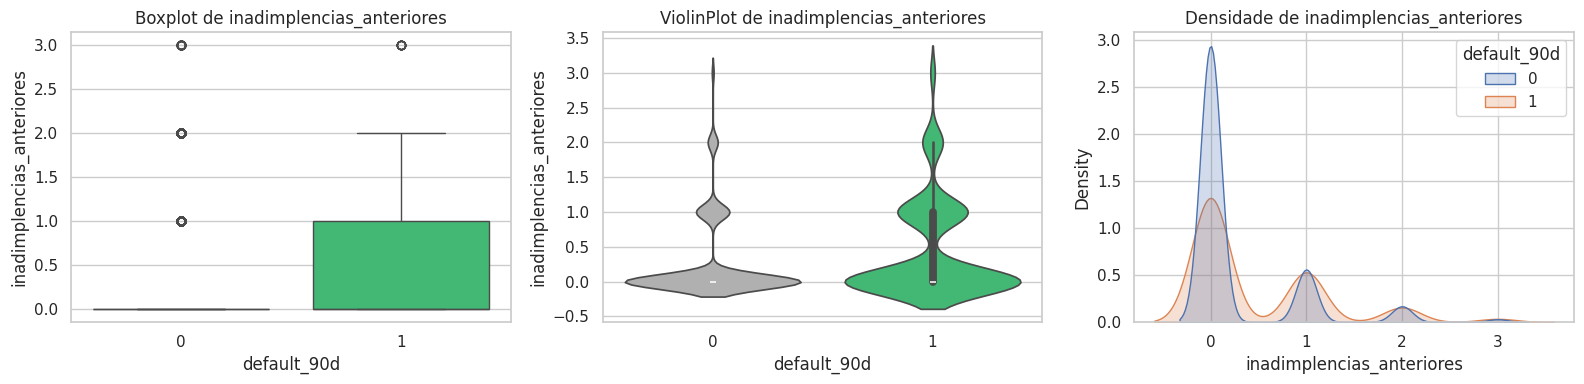

In [16]:
plot_triplo(dados, 'default_90d', 'inadimplencias_anteriores')

## 📊 Score de Crédito

### 🔎 Análise

- Clientes inadimplentes apresentam distribuição deslocada para **scores mais baixos**  
- Clientes adimplentes concentram-se em faixas mais altas de score  
- Existe sobreposição, mas com clara tendência de separação

### 💡 Insight

O score de crédito se confirma como uma variável relevante para discriminação de risco, onde scores mais baixos estão associados a maior probabilidade de inadimplência.

---

## 💰 Taxa de Juros Mensal

### 🔎 Análise

- Clientes inadimplentes tendem a possuir **juros ligeiramente mais altos**  
- Distribuição apresenta leve deslocamento à direita para inadimplentes  

### 💡 Insight

Taxas de juros mais elevadas podem refletir perfis de maior risco já identificados na concessão, além de aumentarem a probabilidade de dificuldade de pagamento.


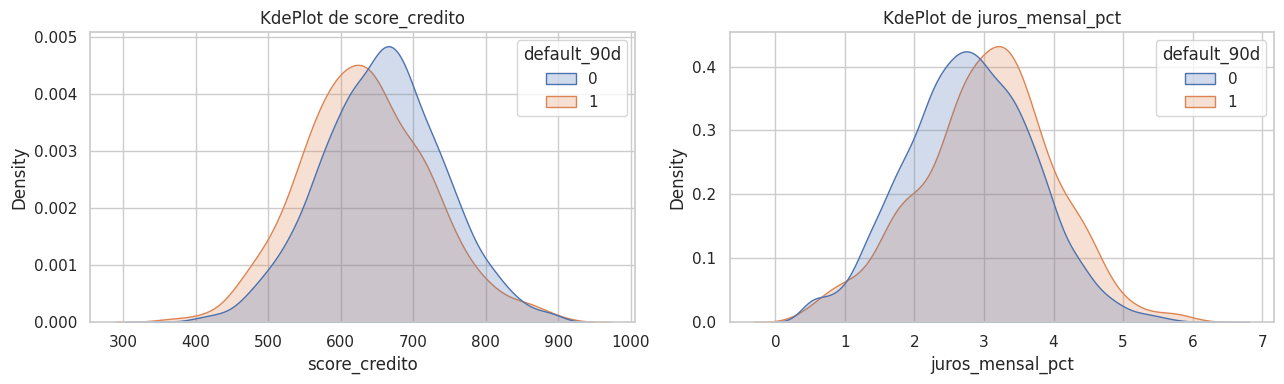

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax = ax.flatten()
colunas = ['score_credito', 'juros_mensal_pct']

for i, col in enumerate(dados[colunas]):
  sns.kdeplot(data=dados, x=col, hue='default_90d', ax=ax[i], fill=True, common_norm=False)
  ax[i].set_title(f'KdePlot de {col}')
  ax[i].set_xlabel(col)

plt.tight_layout()
plt.show()

## 🧩 Análise de Variáveis Categóricas

Nesta etapa, analisamos como a inadimplência (`default_90d`) se distribui entre diferentes categorias, buscando identificar possíveis segmentos de maior risco.

---

## 📱 Canal de Aquisição

### 🔎 Análise

- `parceiro`: maior taxa de inadimplência (~14,4%)  
- `loja`: ~12,7%  
- `site`: ~11,8%  
- `app`: menor taxa (~11,5%)

### 💡 Insight

Clientes adquiridos via **parceiros** apresentam maior risco de inadimplência, possivelmente devido a políticas de crédito menos restritivas ou menor controle na originação.


In [18]:
pd.crosstab(dados['canal_aquisicao'], dados['default_90d'], normalize='index')

default_90d,0,1
canal_aquisicao,,
app,0.885253,0.114747
loja,0.872654,0.127346
parceiro,0.855808,0.144192
site,0.882261,0.117739


## 🌎 Região

### 🔎 Análise

- `Norte`: maior inadimplência (~13,5%)  
- `Nordeste` e `Sudeste`: ~12,6%  
- `Sul`: menor (~11,2%)  
- `Centro-Oeste`: ~10,5%

### 💡 Insight

Há variação regional no risco de crédito, indicando que fatores socioeconômicos podem influenciar o comportamento de pagamento dos clientes.


In [19]:
pd.crosstab(dados['regiao'], dados['default_90d'], normalize='index')

default_90d,0,1
regiao,,
Centro-Oeste,0.895254,0.104746
Nordeste,0.873431,0.126569
Norte,0.864865,0.135135
Sudeste,0.874348,0.125652
Sul,0.887500,0.112500


## 💳 Tipo de Produto

### 🔎 Análise

- `bnpl`: maior inadimplência (~15,8%)  
- `cartao`: ~12,0%  
- `emprestimo_pessoal`: menor (~11,2%)

### 💡 Insight

O produto **BNPL (Buy Now, Pay Later)** apresenta maior risco, possivelmente por facilitar o acesso ao crédito com menor barreira de entrada.


In [20]:
pd.crosstab(dados['tipo_produto'], dados['default_90d'], normalize='index')

default_90d,0,1
tipo_produto,,
bnpl,0.842391,0.157609
cartao,0.879933,0.120067
emprestimo_pessoal,0.887627,0.112373


#3. ⚙️ Feature Engineering

Com o objetivo de capturar melhor o risco financeiro dos clientes, foram criadas novas variáveis derivadas relacionadas ao comprometimento da renda.

### 🔧 Variáveis criadas:

- `comprometimento_renda` = valor_solicitado / renda_mensal  
- `parcela_estimada` = valor_solicitado / prazo_meses  
- `parcela_renda` = parcela_estimada / renda_mensal  

Essas variáveis buscam representar a **capacidade de pagamento do cliente**, um dos principais fatores associados à inadimplência.


In [21]:
dados['comprometimento_renda'] = dados['valor_solicitado'] / dados['renda_mensal']
dados['parcela_estimada'] = dados['valor_solicitado'] / dados['prazo_meses']
dados['parcela_renda'] = dados['parcela_estimada'] / dados['renda_mensal']

## 💸 Comprometimento de Renda

### 🔎 Análise

- Clientes inadimplentes apresentam valores significativamente mais altos  
- Distribuição mais dispersa e com cauda longa para a classe 1  
- Mediana superior em relação aos adimplentes  

### 💡 Insight

Quanto maior o comprometimento da renda, maior a probabilidade de inadimplência, indicando pressão financeira sobre o cliente.


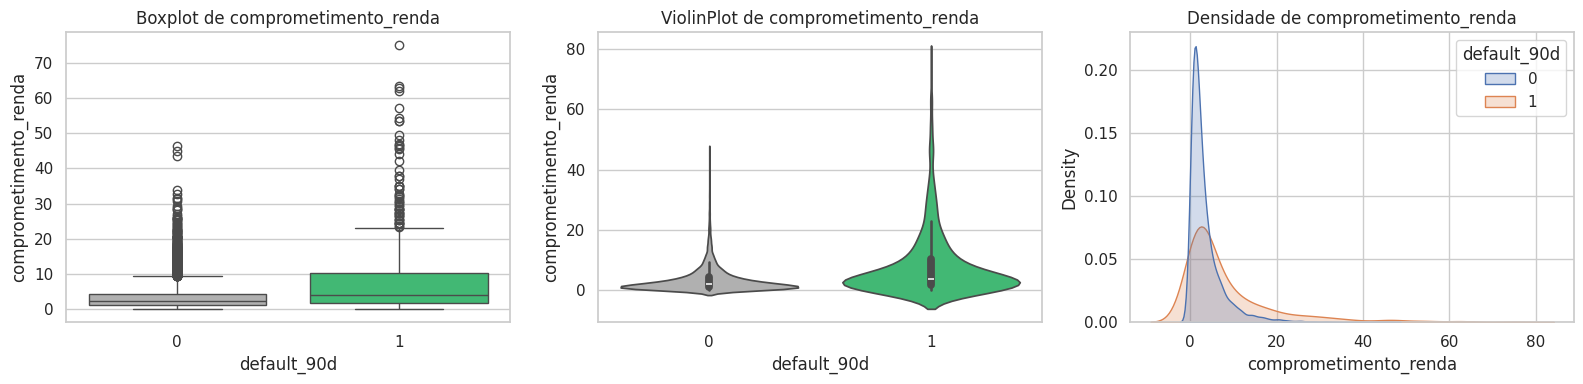

In [22]:
plot_triplo(dados, 'default_90d', 'comprometimento_renda')

## 📊 Parcela Estimada

### 🔎 Análise

- Inadimplentes tendem a possuir parcelas mais elevadas  
- Maior variabilidade e presença de valores extremos  
- Distribuição deslocada para valores maiores na classe 1  

### 💡 Insight

Parcelas mais altas aumentam o risco de inadimplência, especialmente quando não proporcionais à renda do cliente.


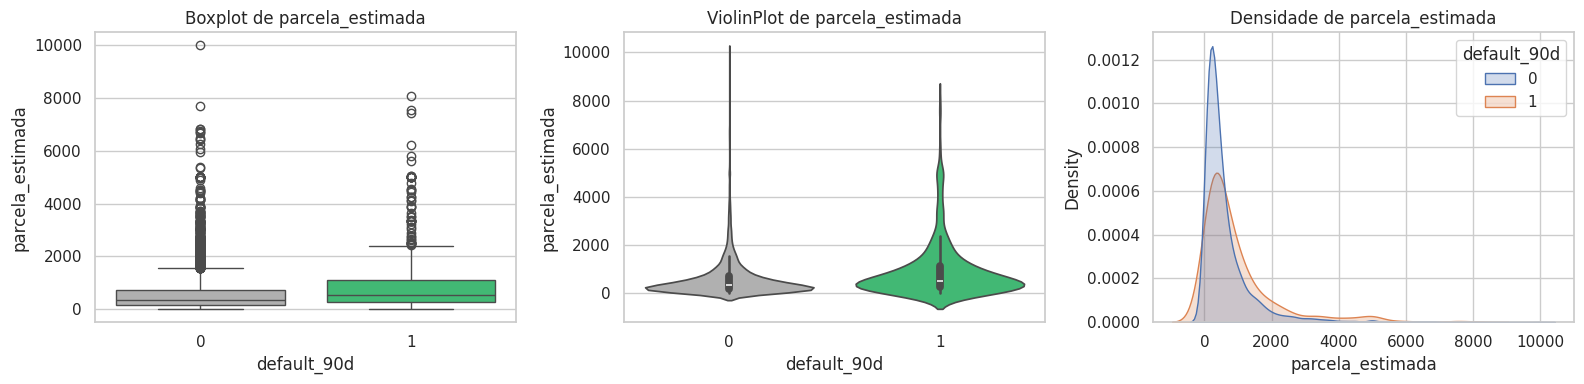

In [23]:
plot_triplo(dados, 'default_90d', 'parcela_estimada')

## ⚖️ Relação Parcela / Renda

### 🔎 Análise

- Variável apresenta clara separação entre as classes  
- Inadimplentes possuem maior proporção da renda comprometida com a parcela  
- Distribuição mais concentrada em valores baixos para adimplentes  

### 💡 Insight

A relação entre parcela e renda se destaca como um dos indicadores mais relevantes de risco, refletindo diretamente a capacidade de pagamento.


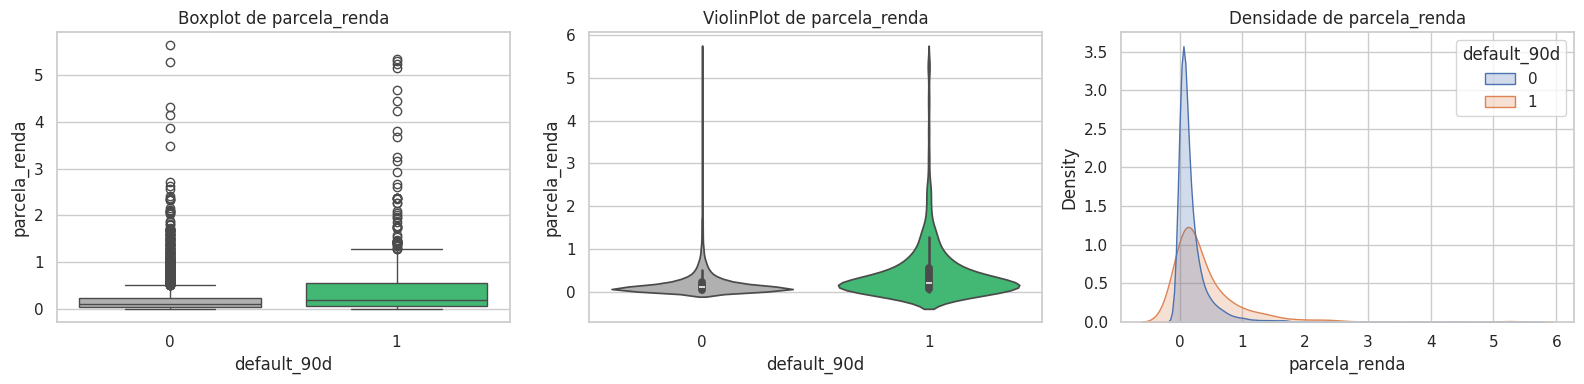

In [24]:
plot_triplo(dados, 'default_90d', 'parcela_renda')

## 📈 Análise de Correlação com Inadimplência

Para complementar a análise exploratória, foi avaliada a correlação entre as variáveis e a variável alvo `default_90d`, com foco nas features mais relevantes identificadas anteriormente.

---

## 🔎 Correlação das Principais Variáveis

### 💸 Comprometimento de Renda
- Correlação: **+0.27**

Indica uma relação positiva moderada com a inadimplência.

### 📊 Parcela Estimada
- Correlação: **+0.14**

Apresenta correlação positiva mais fraca, mas ainda relevante.

### ⚖️ Relação Parcela / Renda
- Correlação: **+0.21**

Mostra associação positiva consistente com o risco de default.

---

## 📊 Outras Variáveis Relevantes

- `valor_solicitado`: **+0.18**  
- `score_credito`: **-0.09**  
- `renda_mensal`: **-0.08**

---

## ⚠️ Interpretação

- Variáveis relacionadas ao **comprometimento financeiro** apresentam as maiores correlações positivas  
- O **score de crédito** e a **renda** possuem correlação negativa, como esperado  
- Nenhuma variável isolada apresenta correlação muito alta, indicando que o problema é **multivariado**

---

## 💡 Insight Principal

As variáveis criadas via feature engineering (`comprometimento_renda`, `parcela_renda`) apresentam maior associação com a inadimplência do que variáveis originais isoladas.

Isso reforça que **combinações de variáveis financeiras capturam melhor o risco real do cliente**.


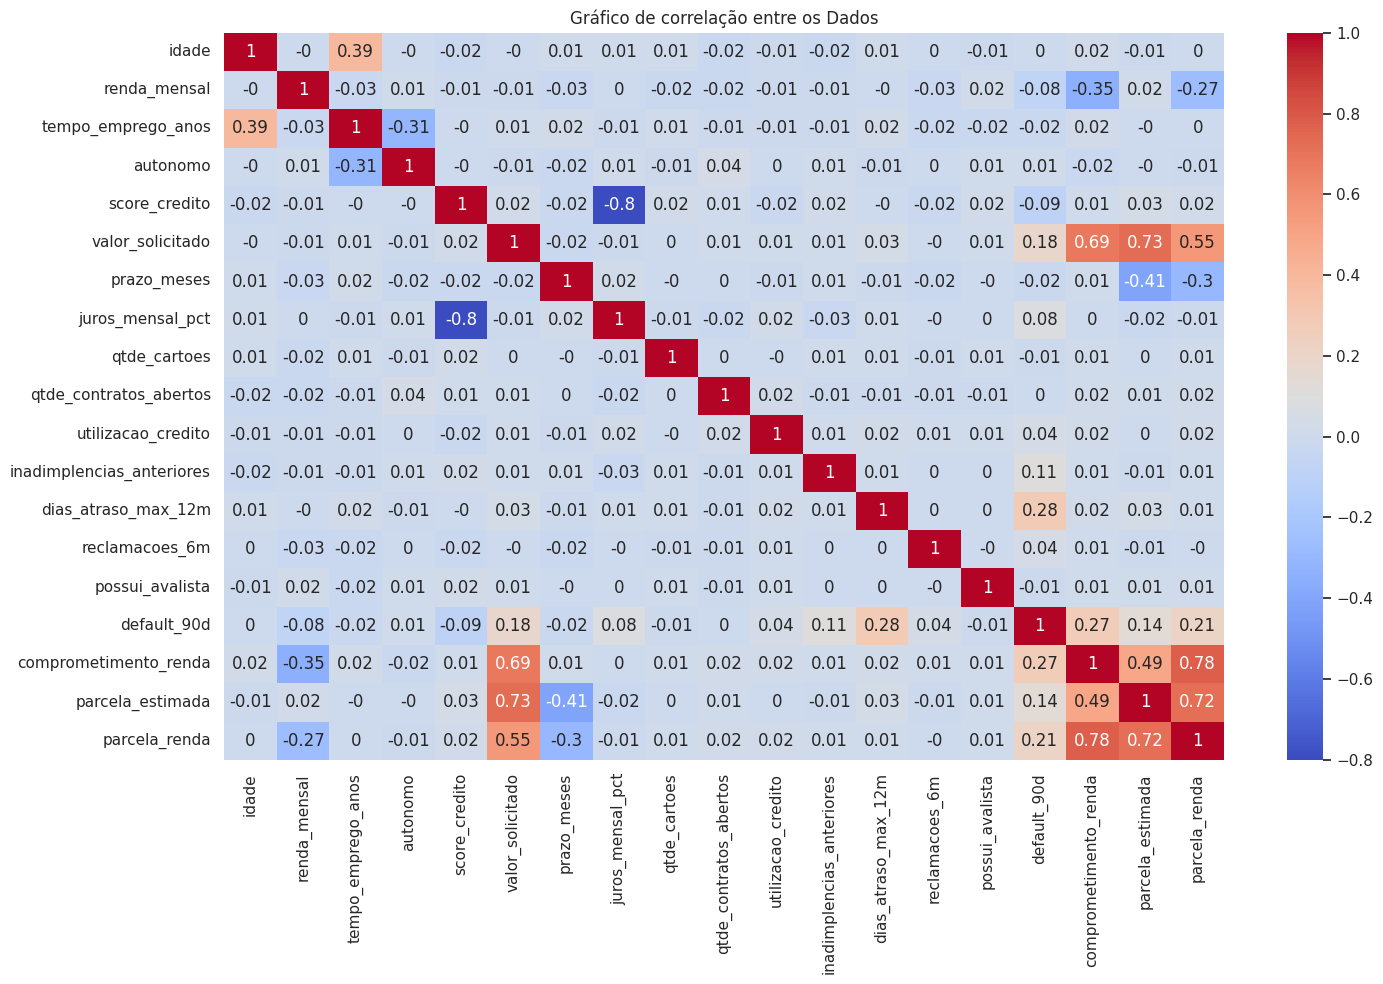

In [27]:

# Pegando a correlação apenas dos dados numéricos
correlacao = dados.select_dtypes(include=[np.number]).corr().round(2)

ax = plt.subplots(figsize=(15,10))
ax = sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title('Gráfico de correlação entre os Dados')
plt.tight_layout()
plt.show()

## 🏁 Conclusão Geral do EDA

A Análise Exploratória de Dados permitiu compreender de forma abrangente os principais fatores associados à inadimplência em operações de crédito.

Ao longo da análise, foi possível identificar que o risco de default não depende de uma única variável isolada, mas sim da combinação de fatores financeiros e comportamentais do cliente.

---

## 🔍 Principais Achados

### 💳 Perfil de Risco
- Clientes inadimplentes tendem a apresentar:
  - **Maior histórico de atrasos**
  - **Registros de inadimplência anteriores**
  - **Scores de crédito mais baixos**

Esses fatores reforçam a importância do comportamento passado como preditor de risco futuro.

---

### 💸 Capacidade de Pagamento
- Variáveis relacionadas ao comprometimento financeiro se destacaram:
  - `comprometimento_renda`
  - `parcela_renda`
  - `valor_solicitado`

Clientes com maior pressão sobre a renda demonstram maior propensão à inadimplência.

---

### 📊 Segmentação de Risco
- Diferenças relevantes foram observadas em:
  - **Canais de aquisição** (maior risco em parceiros)
  - **Tipo de produto** (BNPL com maior inadimplência)
  - **Regiões** (variações regionais no comportamento de pagamento)

Isso evidencia que o risco também está ligado ao contexto de concessão de crédito.

---

### 📈 Consistência dos Resultados
- A análise gráfica (boxplots, densidades)
- A análise estatística (describe)
- E a análise de correlação

apresentaram resultados consistentes, reforçando os mesmos padrões de risco identificados.

---

## 🧠 Insight Final

O risco de inadimplência está fortemente associado a dois pilares principais:

- **Comportamento financeiro passado**  
- **Capacidade atual de pagamento**

Além disso, variáveis derivadas (feature engineering) demonstraram maior capacidade de capturar o risco real do cliente, evidenciando a importância de transformar dados brutos em indicadores mais informativos.

---

## 🚀 Próximos Passos

Com base nos insights obtidos, a base está preparada para:

- Construção de modelos preditivos de risco de crédito  
- Seleção de variáveis mais relevantes  
- Aplicação de técnicas para lidar com desbalanceamento  
- Avaliação de performance com métricas adequadas (AUC, Recall, F1-score)  

---

## 💡 Consideração Final

Este estudo reforça que a análise de crédito eficaz vai além de variáveis isoladas, exigindo uma visão integrada do cliente.

A combinação entre **dados financeiros, comportamento histórico e contexto de aquisição** é essencial para uma avaliação de risco mais precisa e robusta.